# 2.1 Exploratory(探索性) data analysis for house sales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
# 设置 Matplotlib 图形在 Jupyter Notebook 中内联显示为 SVG 矢量格式（分辨率会高一点）
# display.set_matplotlib_formats("svg")
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [17]:
data = pd.read_feather("../house_sales.ftr")

## Let's check the data shape and the first a few examples

In [3]:
data.shape

(164944, 1789)

In [4]:
data.head()

,Id,Address,Sold Price,Sold On,Summary,Type,Year built,Heating,Cooling,Parking,...,Well Disclosure,remodeled,DOH2,SerialX,Full Baths,Tax Legal Lot Number,Tax Legal Block Number,Tax Legal Tract Number,Building Name,Zip
0,2080183300,"11205 Monterey,","$2,000,000",01/31/20,"11205 Monterey, San Martin, CA 95046 is a sing...",SingleFamily,No Data,No Data,No Data,0 spaces,...,None,None,None,None,None,None,None,None,None,95046
1,20926300,"5281 Castle Rd,","$2,100,000",02/25/21,Spectacular Mountain and incredible L.A. City ...,SingleFamily,1951,Central,"Central Air, Dual","Driveway, Driveway - Brick",...,None,None,None,None,None,None,None,None,None,91011
2,19595300,"3581 Butcher Dr,","$1,125,000",11/06/19,Eichler Style home! with Santa Clara High! in ...,SingleFamily,1954,Central Forced Air - Gas,Central AC,"Garage, Garage - Attached, Covered",...,None,None,None,None,None,None,None,None,None,95051
3,300472200,"2021 N Milpitas Blvd,","$36,250,000",10/02/20,"2021 N Milpitas Blvd, Milpitas, CA 95035 is a ...",Apartment,1989,Other,No Data,"Mixed, Covered",...,None,None,None,None,None,None,None,None,None,95035
4,2074492000,"LOT 4 Tool Box Spring Rd,","$140,000",10/19/20,Beautiful level lot dotted with pine trees ro...,VacantLand,No Data,No Data,No Data,0 spaces,...,None,None,None,None,None,None,None,None,None,92561


## Drop(删除) columns that at least 30% values are null

In [18]:
# data.isnull()：生成与 data 形状相同的布尔 DataFrame，缺失值为 True
# .sum()：默认按列求和，True 计为 1，因此得到每列缺失值总数
null_sum = data.isnull().sum()
data.columns[null_sum < len(data) * 0.3]  # columns will keep

Index(['Id', 'Address', 'Sold Price', 'Sold On', 'Summary', 'Type',
       'Year built', 'Heating', 'Cooling', 'Parking', 'Bedrooms', 'Bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Home type', 'Region', 'Elementary School', 'Elementary School Score',
       'Elementary School Distance', 'High School', 'High School Score',
       'High School Distance', 'Heating features', 'Parking features',
       'Lot size', 'Parcel number', 'Tax assessed value', 'Annual tax amount',
       'Listed On', 'Listed Price', 'Zip'],
      dtype='object')

In [19]:
# drop data
data.drop(columns=data.columns[null_sum > len(data) * 0.3], inplace=True)

## check the data types

In [20]:
data.dtypes

Id                             object
Address                        object
Sold Price                     object
Sold On                        object
Summary                        object
Type                           object
Year built                     object
Heating                        object
Cooling                        object
Parking                        object
Bedrooms                       object
Bathrooms                      object
Total interior livable area    object
Total spaces                   object
Garage spaces                  object
Home type                      object
Region                         object
Elementary School              object
Elementary School Score        object
Elementary School Distance     object
High School                    object
High School Score              object
High School Distance           object
Heating features               object
Parking features               object
Lot size                       object
Parcel numbe

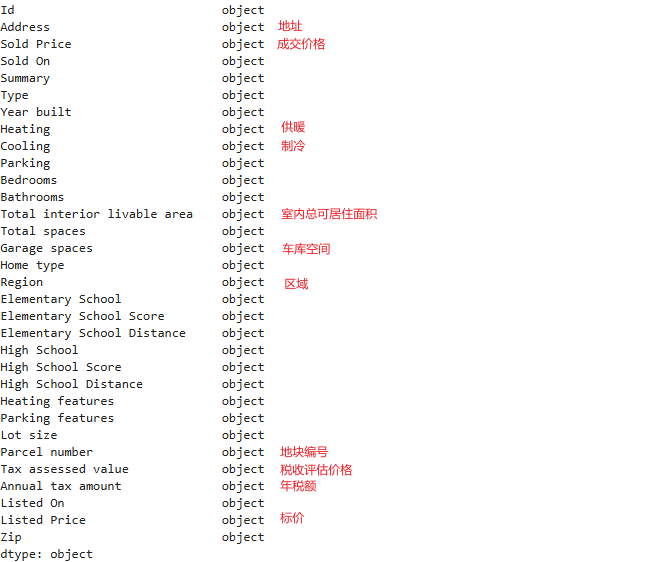

## Conver(转换) currency(货币) from string format to float

In [21]:
currency = ["Sold Price", "Listed Price", "Tax assessed value", "Annual tax amount"]
for c in currency:
    data[c] = data[c].replace(
        # 第一步：移除字符串中的 $、,、- 字符
        # 正则 r"[$,-]"：
        #   $ 在字符类中不需要转义，表示美元符号
        #   , 表示逗号（千分位分隔符）
        #   - 表示没有数据
        # regex=True 表示使用正则表达式匹配
        r"[$,-]", "", regex=True).replace(
        # 第二步：将空字符串或仅包含空白的字符串替换为 NaN
        # 正则 r"^\s*$"：
        #   ^     表示字符串开始
        #   \s*   表示零个或多个空白字符（空格、制表符等）
        #   $     表示字符串结束
        # 因此该表达式匹配完全为空或只含空白字符的单元格
        # 将其替换为 np.nan
        r"^\s*$", np.nan, regex=True).astype(float)

## Convert areas from string format to float

In [23]:
areas = ["Total interior livable area", "Lot size"]
for c in areas:
    acres = data[c].str.contains("Acres") == True
    col = data[c].replace(r"\b sqft\b|\b Acres\b|\b,\b", "", regex=True).astype(float)
    col[acres] *= 43560
    data[c] = col

## Check values of the numerical(数字的) columns. The min and max values for several(一些) columns do not make sense(意义)

In [25]:
data.describe()

,Sold Price,Total interior livable area,Lot size,Tax assessed value,Annual tax amount,Listed Price
count,1.648590e+05,1.465450e+05,1.358450e+05,1.450650e+05,1.433500e+05,1.250060e+05
mean,1.194842e+06,3.182221e+03,9.525061e+05,8.898781e+05,1.123415e+04,1.197671e+06
std,3.336365e+06,4.609881e+05,1.357197e+08,3.126888e+06,3.859389e+04,2.874721e+06
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,4.350000e+05,1.170000e+03,4.800000e+03,2.550000e+05,3.434250e+03,4.990000e+05
50%,8.050000e+05,1.558000e+03,6.603000e+03,5.635010e+05,7.372000e+03,8.490000e+05
75%,1.370000e+06,2.144000e+03,1.209000e+04,1.033832e+06,1.321300e+04,1.395000e+06
max,8.660000e+08,1.764164e+08,4.856770e+10,8.256328e+08,9.977342e+06,6.250000e+08


## Filter(过滤) out houses whose living areas are too small or too hard to simplify the visualization(可视化) later.

In [26]:
abnormal = (data[areas[1]] < 10) | (data[areas[1]] > 1e4)
# data[~abnormal] 会返回 abnormal 为 False 的那些行，即过滤掉异常行
data = data[~abnormal]
# abnormal 中 True 的个数，即异常样本的总数
sum(abnormal)

41000

## Check the histogram(直方图) of the "Sold Price", which is the target we want to predict

[Text(3, 0, '1e+03'),
 Text(4, 0, '1e+04'),
 Text(5, 0, '1e+05'),
 Text(6, 0, '1e+06'),
 Text(7, 0, '1e+07'),
 Text(8, 0, '1e+08')]

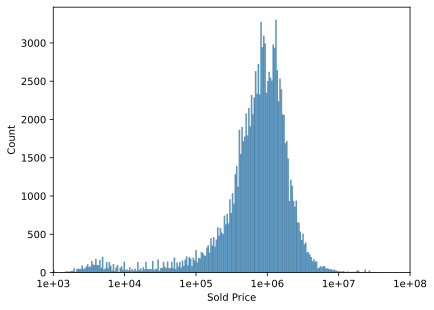

In [27]:
# 加上 log10 数据可视化可以均匀一些
ax = sns.histplot(np.log10(data["Sold Price"]))
# 设置 x 轴显示范围（log10 尺度）为 3 到 8，即原始值的 10^3 到 10^8
ax.set_xlim([3, 8])
# 设置 x 轴刻度位置：3,4,5,6,7,8（对应 log10 值）
ax.set_xticks(range(3, 9))
ax.set_xticklabels(["%.0e"%a for a in 10 ** ax.get_xticks()])

## A house has different types.

In [30]:
# [0:20]：对结果进行切片，取前 20 行（即出现频率最高的 20 个类型）。
# 如果唯一值不足 20 个，则返回全部。
data["Type"].value_counts()[0:20]

Type
SingleFamily            74318
Condo                   18749
MultiFamily              6586
VacantLand               6199
Townhouse                5846
Unknown                  5390
MobileManufactured       2588
Apartment                1416
Cooperative               161
Residential Lot            75
Single Family              69
Single Family Lot          56
Acreage                    48
2 Story                    39
3 Story                    25
Hi-Rise (9+), Luxury       21
Condominium                19
Duplex                     19
RESIDENTIAL                19
Mid-Rise (4-8)             17
Name: count, dtype: int64

## Price density(密度) for different house types.

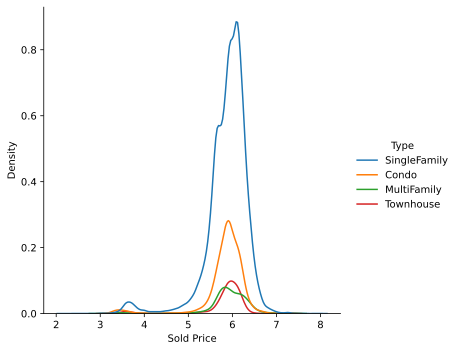

In [32]:
types = data["Type"].isin(["SingleFamily", "Condo", "MultiFamily", "Townhouse"])
sns.displot(pd.DataFrame({"Sold Price":np.log10(data[types]["Sold Price"]),
                          "Type":data[types]["Type"]}),
                    x = "Sold Price", 
                    hue="Type", 
                    # 指定图形类型为 KDE（核密度估计）
                    kind="kde")

## Another important measurement(指标) is the sale price per living sqft.

(0.0, 2000.0)

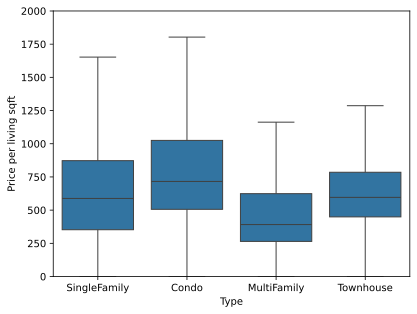

In [33]:
data["Price per living sqft"] = data["Sold Price"] / data["Total interior livable area"]
ax = sns.boxplot(x="Type", y="Price per living sqft", data=data[types], fliersize=0)
ax.set_ylim([0, 2000])

## The location affect the price 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17004\1606366280.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


[Text(0, 0, '95118'),
 Text(1, 0, '94043'),
 Text(2, 0, '95131'),
 Text(3, 0, '94110'),
 Text(4, 0, '94123'),
 Text(5, 0, '90003'),
 Text(6, 0, '94114'),
 Text(7, 0, '95123'),
 Text(8, 0, '94118'),
 Text(9, 0, '94122'),
 Text(10, 0, '95122'),
 Text(11, 0, '94103'),
 Text(12, 0, '90011'),
 Text(13, 0, '94117'),
 Text(14, 0, '94089'),
 Text(15, 0, '94112'),
 Text(16, 0, '94131'),
 Text(17, 0, '94115'),
 Text(18, 0, '94121'),
 Text(19, 0, '94116')]

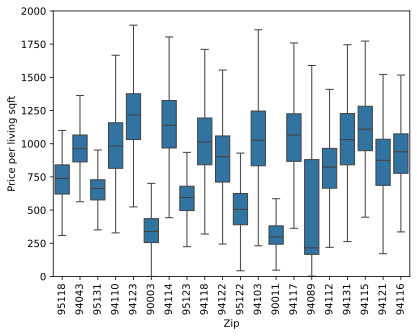

In [34]:
d = data[data["Zip"].isin(data["Zip"].value_counts()[:20].keys())]
ax = sns.boxplot(x="Zip", y="Price per living sqft", data=d, fliersize=0)
ax.set_ylim([0, 2000])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

## Visualize the correlation(相关性) matrix(矩阵) of several columns.

<Axes: >

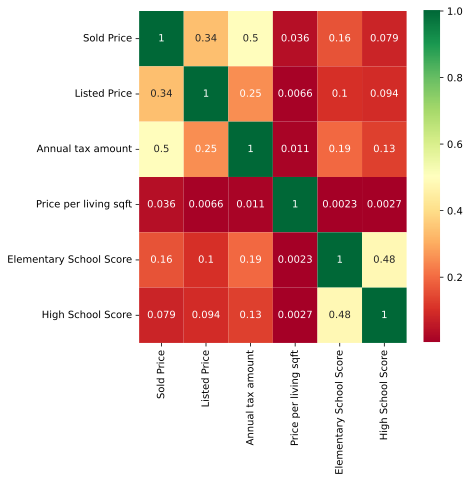

In [35]:
_, ax = plt.subplots(figsize=(6, 6))
columns = ["Sold Price", "Listed Price", "Annual tax amount", "Price per living sqft", "Elementary School Score", "High School Score"]
# .corr() 计算这个子 DataFrame 各列之间的皮尔逊相关系数矩阵
# annot=True 表示在每个单元格中显示数值（即相关系数）
# cmap="RdYlGn" 设置颜色映射方案
# RdYlGn 是红-黄-绿渐变，通常用来表示从负相关（红）到零相关（黄）再到正相关（绿）
sns.heatmap(data[columns].corr(), annot=True, cmap="RdYlGn", ax=ax)